In [5]:
# ==========================================
#  SIX SIGMA ANALYSIS — EMERGENCY DEPARTMENT
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# ----------------------------
# 1. Load and prepare the data
# ----------------------------

# load csv
df = pd.read_csv("../data/emergency_service.csv", delimiter=";", encoding="latin1")

# Convert numeric columns (commas -> dots)
for col in ["Length of stay_min", "KTAS duration_min"]:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .astype(float)
    )

# drop missing LOS values
df = df.dropna(subset=["Length of stay_min"])

In [ ]:
# ----------------------------
# 2. Filter out extreme outliers
# ----------------------------
# remove outliers (overly long stays)
df_filtered = df[df["Length of stay_min"] <= 720].copy()

print(f"Original cases: {len(df)}")
print(f"Filtered cases: {len(df_filtered)}")

Original cases: 1267
Filtered cases: 983


In [ ]:
# ----------------------------
# 3. Define target and defects
# ----------------------------
USL = 120  # assuming hospital target: ≤ 120 min (2 hours)
df_filtered["defect"] = (df_filtered["Length of stay_min"] > USL).astype(int)

total_cases = len(df_filtered)
defects = df_filtered["defect"].sum()
DPO = defects / total_cases
DPMO = DPO * 1_000_000

print("\n--- Defect Summary ---")
print(f"Total cases: {total_cases}")
print(f"Defects (>120 min): {defects}")
print(f"DPO: {DPO:.4f}")
print(f"DPMO: {DPMO:.0f}")



--- Defect Summary ---
Total cases: 983
Defects (>120 min): 706
DPO: 0.7182
DPMO: 718210


In [9]:
# ----------------------------
# 4. Process Capability (Cpk)
# ----------------------------
mean = df_filtered["Length of stay_min"].mean()
std = df_filtered["Length of stay_min"].std(ddof=1)
Cpk = (USL - mean) / (3 * std)

print("\n--- Process Capability ---")
print(f"Mean: {mean:.2f} min")
print(f"Std deviation: {std:.2f} min")
print(f"Cpk: {Cpk:.2f}")


--- Process Capability ---
Mean: 240.84 min
Std deviation: 170.47 min
Cpk: -0.24


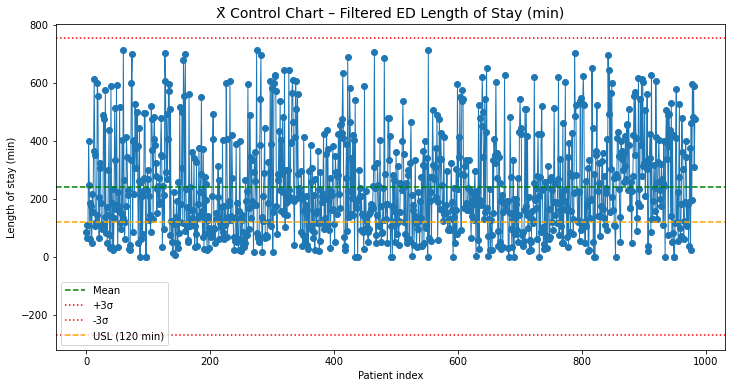

In [10]:
# ----------------------------
# 5. Control Chart (X̄ Chart)
# ----------------------------
plt.figure(figsize=(12, 6))
plt.plot(df_filtered["Length of stay_min"].values, marker="o", linewidth=1)
plt.axhline(mean, color="green", linestyle="--", label="Mean")
plt.axhline(mean + 3 * std, color="red", linestyle=":", label="+3σ")
plt.axhline(mean - 3 * std, color="red", linestyle=":", label="-3σ")
plt.axhline(USL, color="orange", linestyle="--", label="USL (120 min)")
plt.title("X̄ Control Chart – Filtered ED Length of Stay (min)", fontsize=14)
plt.xlabel("Patient index")
plt.ylabel("Length of stay (min)")
plt.legend()
plt.show()


In [ ]:
# ----------------------------
# 6. Quick Summary (for automation)
# ----------------------------
if Cpk >= 1.33:
    rating = "Capable (meets Six Sigma quality standards)"
elif Cpk >= 1.0:
    rating = "Moderately capable, some improvement needed"
else:
    rating = "Not capable – process exceeds spec limits frequently"

print("\nProcess Summary:")
print(f"• Mean LOS = {mean:.1f} min")
print(f"• Std Dev = {std:.1f} min")
print(f"• Defect Rate = {DPO*100:.1f}% ({DPMO:.0f} per million)")
print(f"• Capability Index (Cpk) = {Cpk:.2f} → {rating}")


Process Summary:
• Mean LOS = 240.8 min
• Std Dev = 170.5 min
• Defect Rate = 71.8% (718210 per million)
• Capability Index (Cpk) = -0.24 → Not capable – process exceeds spec limits frequently


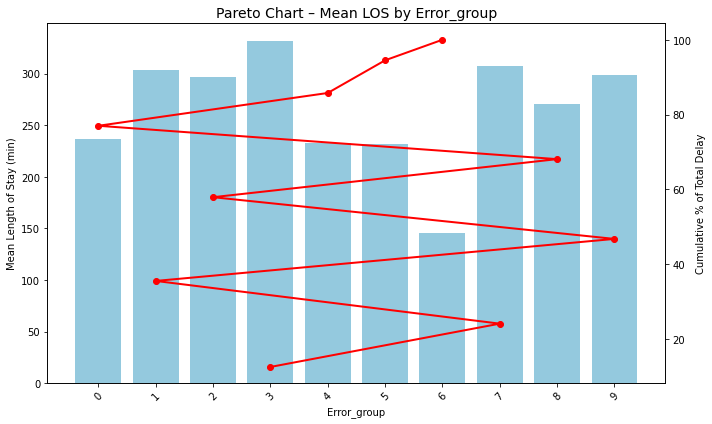

The category with the highest mean LOS is '3.0' with an average of 332.0 minutes.
→ According to the Pareto principle, focus first on the top 20% of factors that explain roughly 80% of delay.


In [15]:
# ==========================================
# 7. Root-Cause Analysis – Pareto Chart
# ==========================================
import seaborn as sns

# ---- choosing categorical variable to test
#rerun with "mistriage" or "Group"
root_cause_col = "Error_group"

# ---- computing average LOS and count per category
pareto_df = (
    df_filtered.groupby(root_cause_col, as_index=False)
    .agg(mean_LOS=("Length of stay_min", "mean"),
         count=("Length of stay_min", "size"))
    .sort_values("mean_LOS", ascending=False)
)

# ---- calculating cumulative % of total delay
pareto_df["cum_pct"] = pareto_df["mean_LOS"].cumsum() / pareto_df["mean_LOS"].sum() * 100

# ---- plotting dual-axis Pareto chart
fig, ax1 = plt.subplots(figsize=(10,6))
sns.barplot(data=pareto_df, x=root_cause_col, y="mean_LOS", color="skyblue", ax=ax1)
ax2 = ax1.twinx()
ax2.plot(pareto_df[root_cause_col], pareto_df["cum_pct"], color="red", marker="o", linewidth=2)

ax1.set_title(f"Pareto Chart – Mean LOS by {root_cause_col}", fontsize=14)
ax1.set_xlabel(root_cause_col)
ax1.set_ylabel("Mean Length of Stay (min)")
ax2.set_ylabel("Cumulative % of Total Delay")
ax1.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

# ---- interpretation aid
top_factor = pareto_df.iloc[0][root_cause_col]
top_value = pareto_df.iloc[0]["mean_LOS"]
print(f"The category with the highest mean LOS is '{top_factor}' "
      f"with an average of {top_value:.1f} minutes.")
print("→ According to the Pareto principle, focus first on the top 20% of factors "
      "that explain roughly 80% of delay.")
